# Import Statements

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load the Dataset

In [2]:
df1 = pd.read_csv("wine+quality/winequality-red.csv", sep=";")
df1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [3]:
df2 = pd.read_csv("wine+quality/winequality-white.csv", sep=";")
df2

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


### Concatenating the two datasets

In [4]:
# Concatenate DataFrames along rows
merged_df = pd.concat([df1, df2], axis=0, ignore_index=True)

In [5]:
merged_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


### Saving the merged Dataframe

In [6]:
merged_df.to_csv("WineQualityDatabase.csv")

In [7]:
merged_df = pd.read_csv("WineQualityDatabase.csv")
merged_df.head()

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# Data Inspection

Checking various features of the data to understand it better.

In [8]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            6497 non-null   int64  
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [9]:
merged_df.describe()

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,3248.000000,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1875.666681,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,0.000000,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,1624.000000,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,3248.000000,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,4872.000000,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,6496.000000,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


The statistics show the stats for every column.

In [10]:
merged_df.isna().sum()

Unnamed: 0              0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

This indicates that our DataFrame has no null values and hence no need to remove any of them.

In [11]:
merged_df.dtypes

Unnamed: 0                int64
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

All of the columns are either int or float which makes it perfect for the machine learning model.

In [12]:
duplicate = merged_df[merged_df.duplicated()]
duplicate

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality


The result shows that the data contains no duplicate entries. 

### Creating Box Plots to visualize the OutLiers

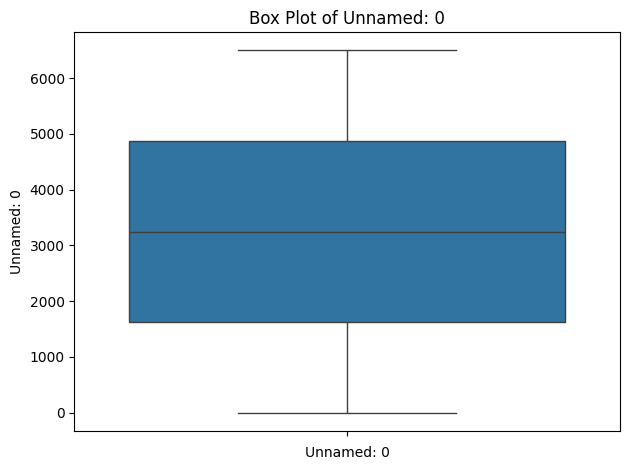

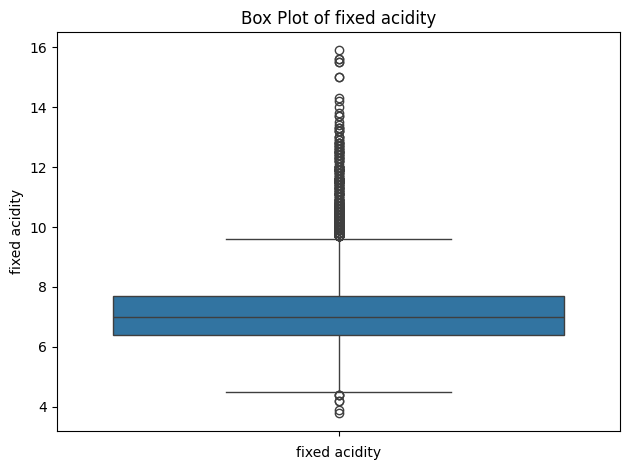

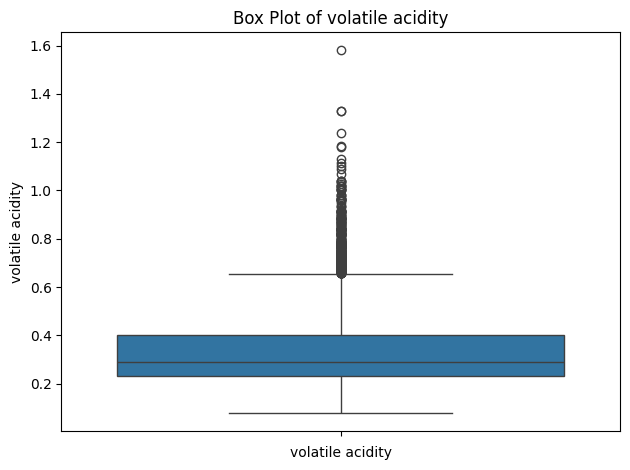

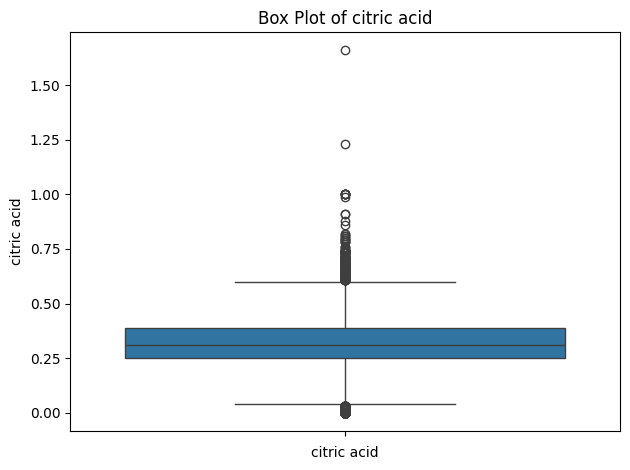

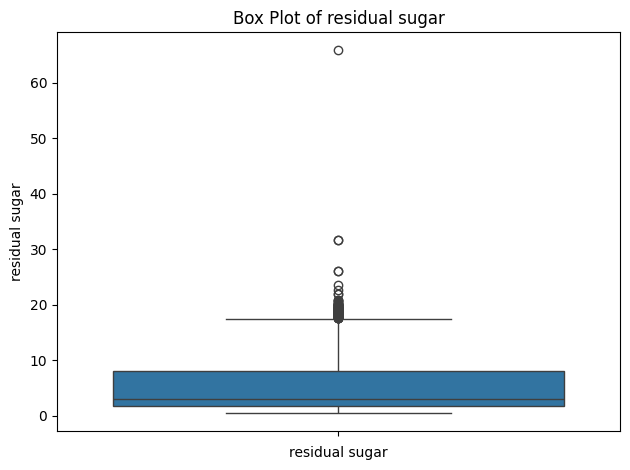

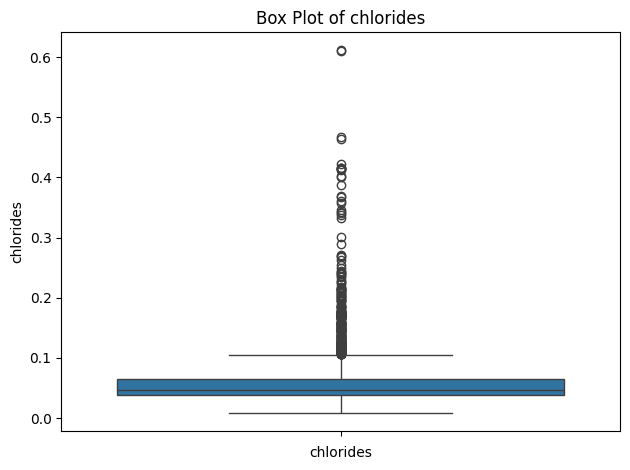

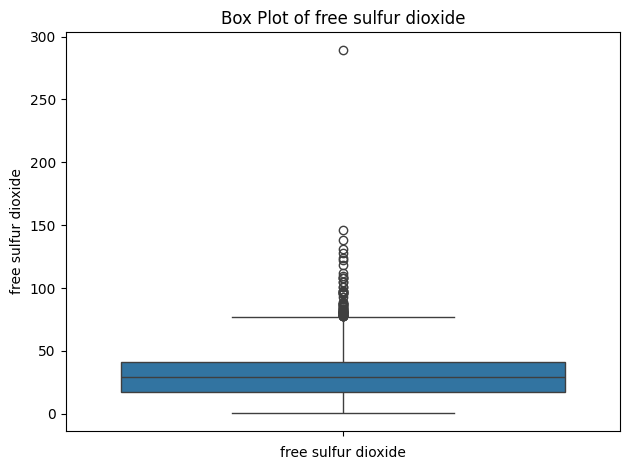

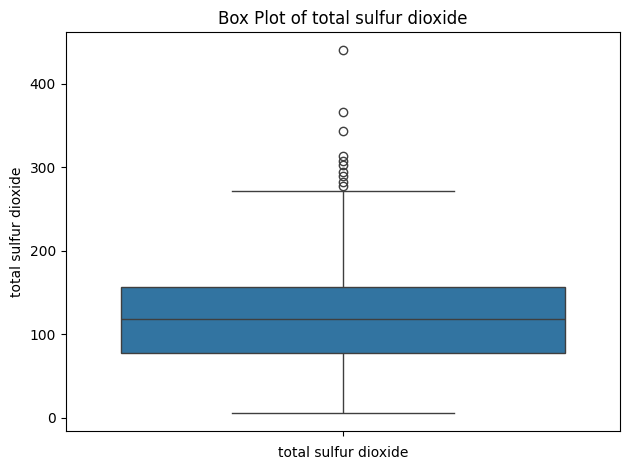

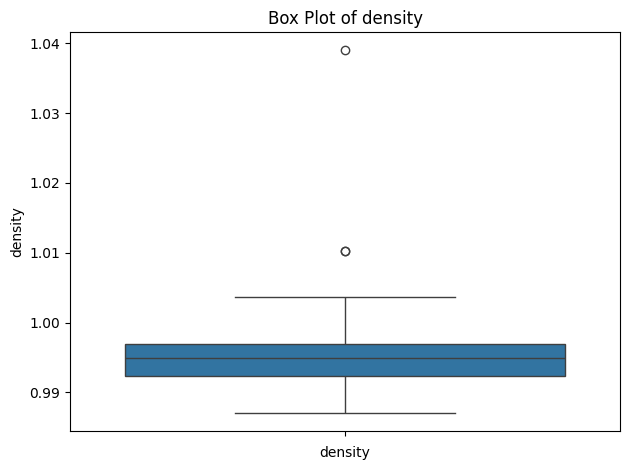

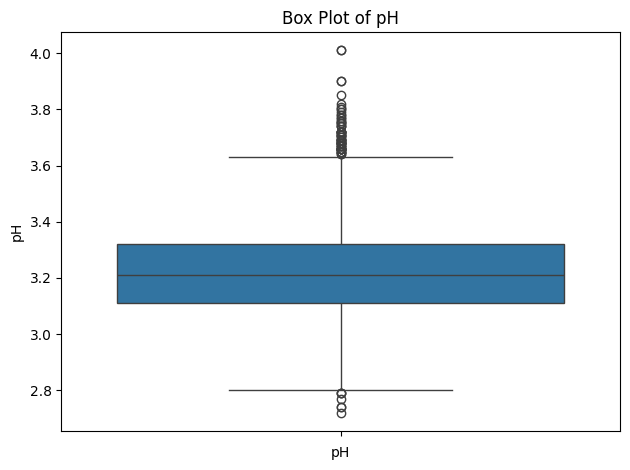

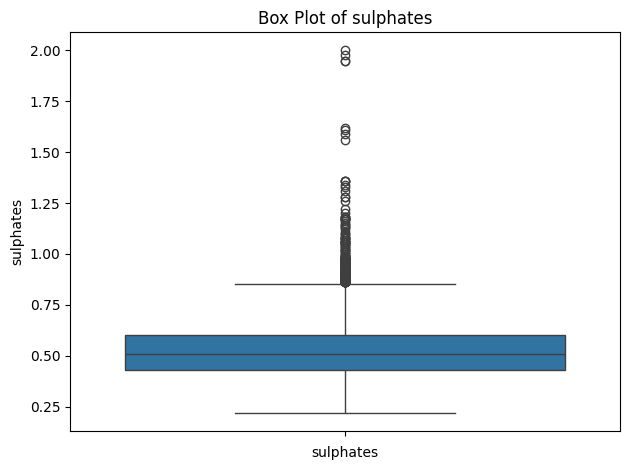

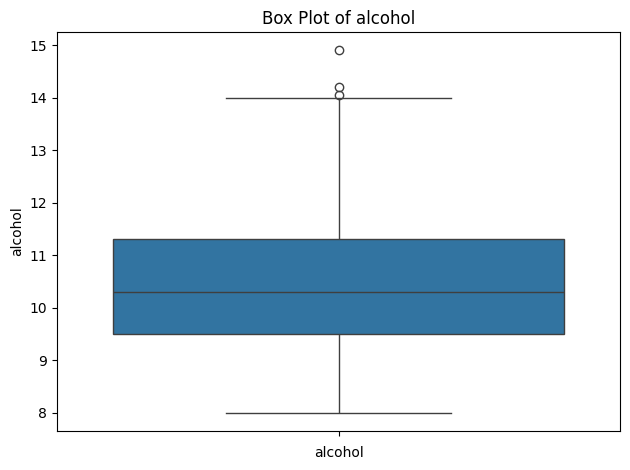

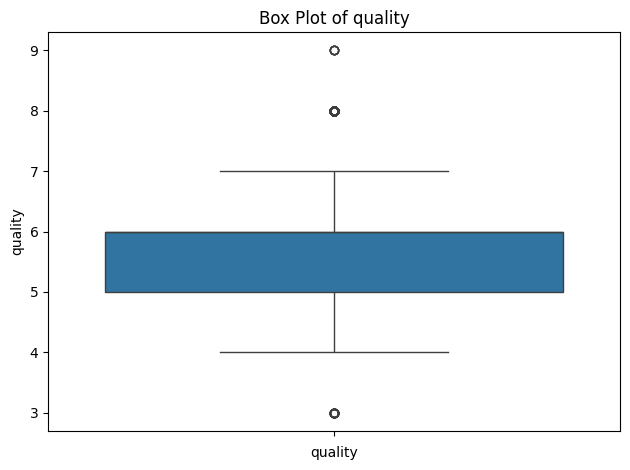

In [13]:
for i, column in enumerate(merged_df.columns):
    sns.boxplot(data=merged_df[column])            # Create box plot
    plt.title(f'Box Plot of {column}')      # Title of the plot
    plt.xlabel(column)                      # Label for x-axis

    plt.tight_layout()  # Adjust subplots to fit into figure area.
    plt.show()         # Display all plots


The box plot shows outliers in every column of the dataframe and hence each outlier needs to be tackled.

### Using Bar Chart to check the Data Division among the classes

In [14]:
# Count the number of occurrences of each class
class_counts = merged_df['quality'].value_counts()
class_counts

quality
6    2836
5    2138
7    1079
4     216
8     193
3      30
9       5
Name: count, dtype: int64

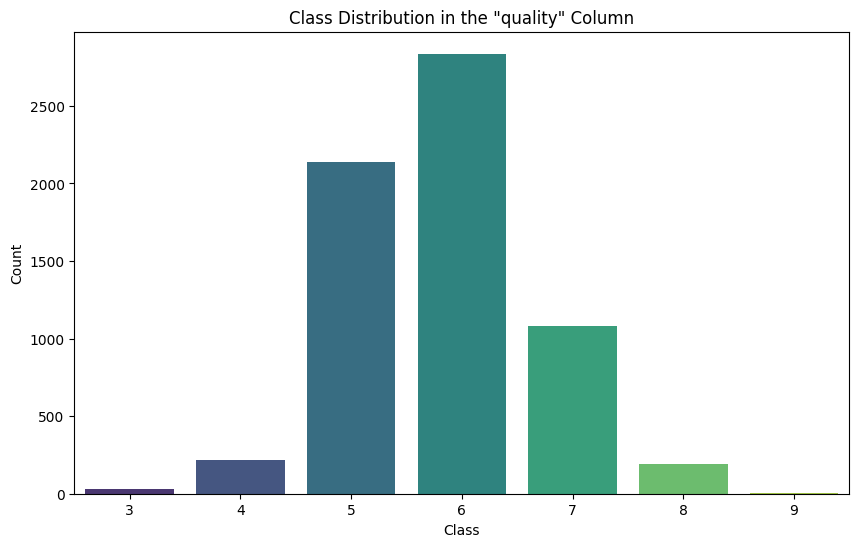

In [15]:
def bar_chart(class_counts):
    # Set the figure size
    plt.figure(figsize=(10, 6))
    
    # Create a bar plot
    sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
    
    # Add titles and labels
    plt.title('Class Distribution in the "quality" Column')
    plt.xlabel('Class')
    plt.ylabel('Count')
    
    # Show the plot
    plt.show()

bar_chart(class_counts)

This shows that our wine is scaled on a measure of 3 to 9 where most of them lies on average scale which is 5 or 6.

# Data Cleaning

Since the data has no null values or duplicate rows to tackle, we will move directly to outlier removal.

### Outlier Removal

In [16]:
df_cleaned = merged_df.copy()
df_cleaned

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [17]:
def remove_outlier(df_cleaned):
    for column in df_cleaned.columns:
        if column == "quality":
            break
        # Calculate Q1 (25th percentile) and Q3 (75th percentile)
        Q1 = df_cleaned[column].quantile(0.25)
        Q3 = df_cleaned[column].quantile(0.75)
        
        # Calculate IQR (Interquartile Range)
        IQR = Q3 - Q1
        
        # Define the outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Remove outliers
        df_cleaned = df_cleaned[(df_cleaned[column] >= lower_bound) & (df_cleaned[column] <= upper_bound)]
        
    return df_cleaned

df_cleaned = remove_outlier(df_cleaned)

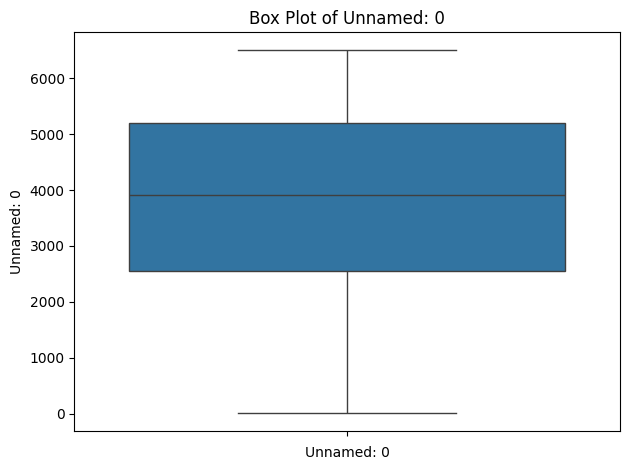

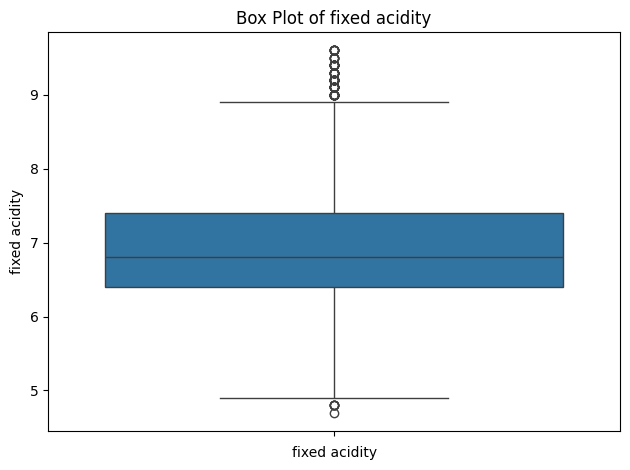

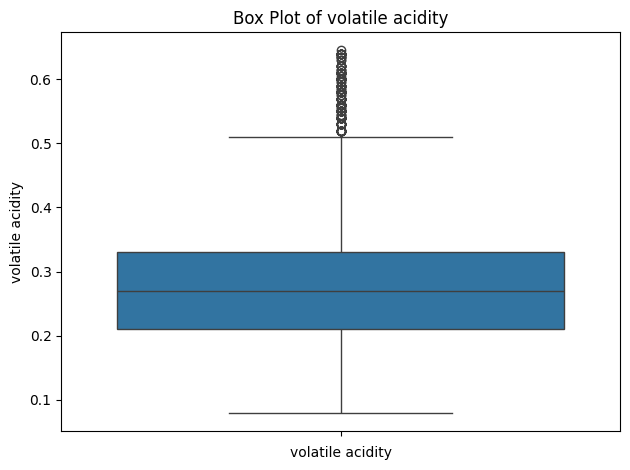

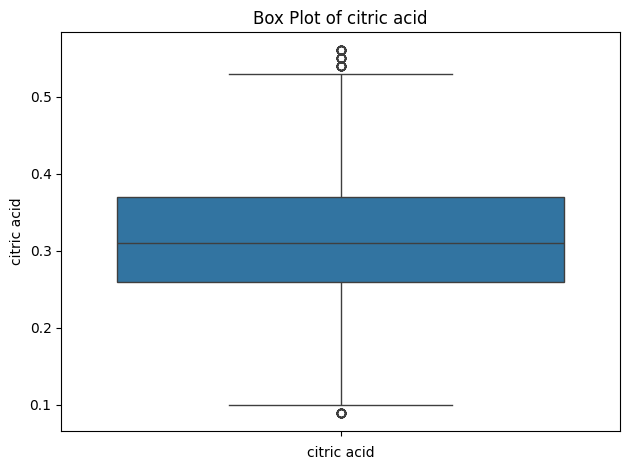

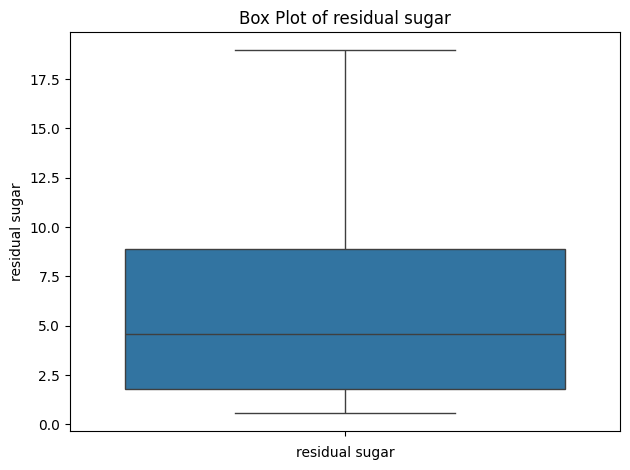

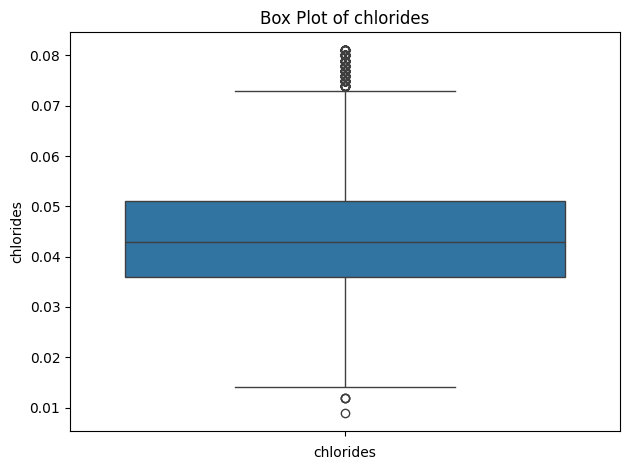

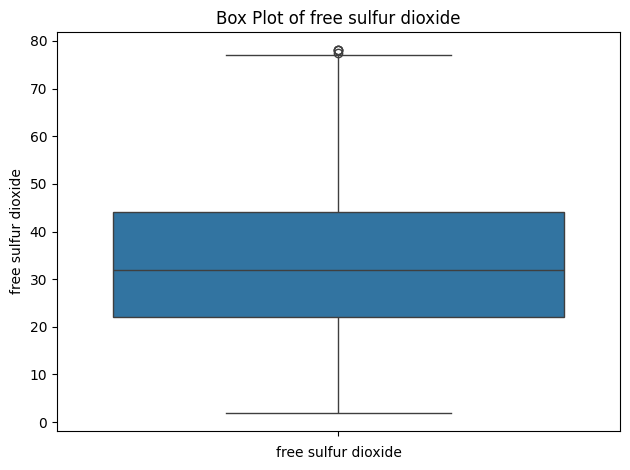

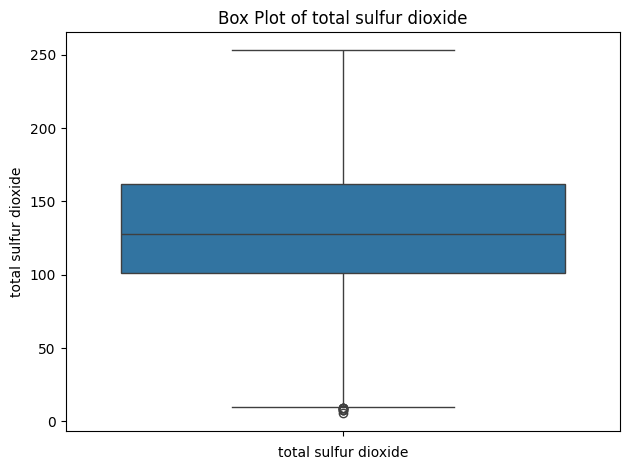

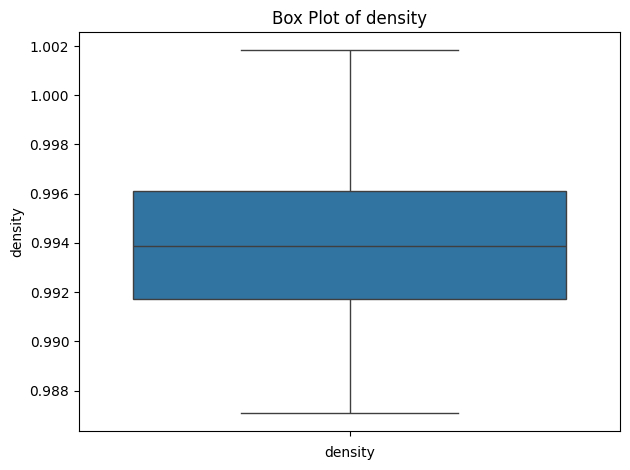

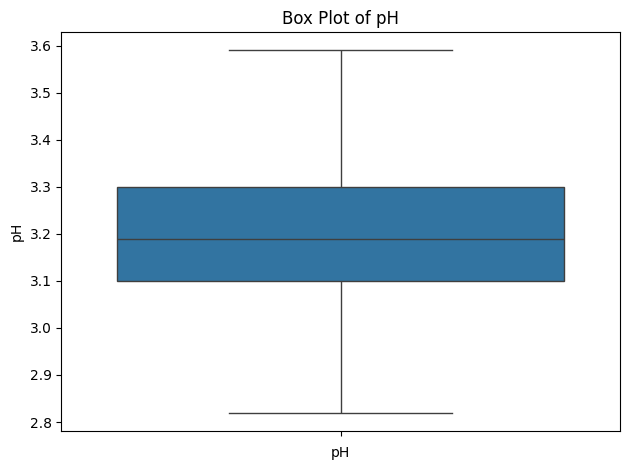

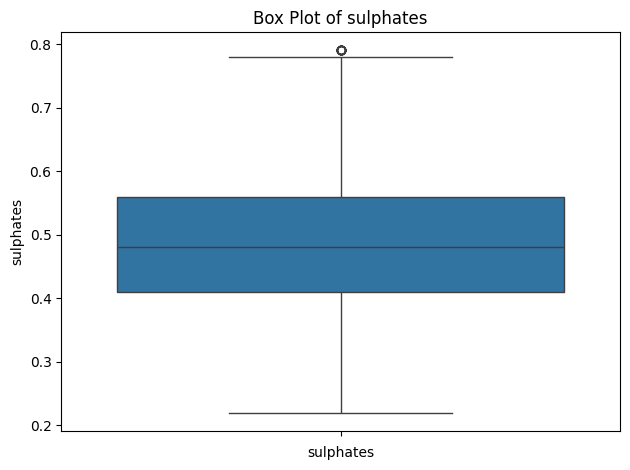

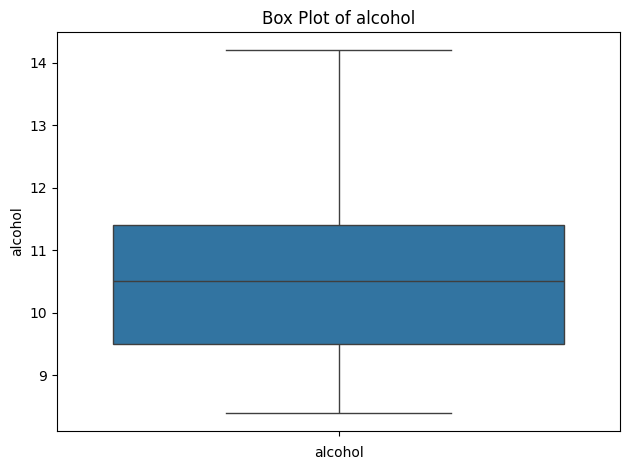

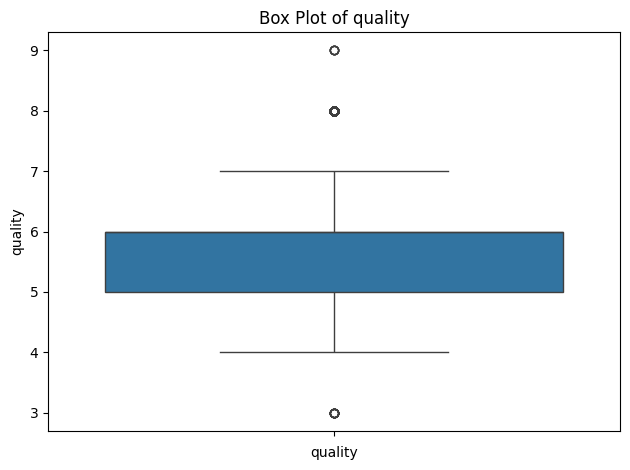

In [18]:
def box_plot(df_cleaned):
    for i, column in enumerate(df_cleaned.columns):
        sns.boxplot(data=df_cleaned[column])            # Create box plot
        plt.title(f'Box Plot of {column}')      # Title of the plot
        plt.xlabel(column)                      # Label for x-axis
    
        plt.tight_layout()  # Adjust subplots to fit into figure area.
        plt.show()         # Display all plots

box_plot(df_cleaned)

Even after applying this method **fixed acidity, volatile acidity and chlorides** have outliers left. Although citric acid, free sulfur dioxide, total sulfur dioxide and sulphated also do have outliers but this is quite negligible in this.

Applying the method one more_time removes maximum number of outliers and makes it almost negligible.

In [19]:
df_cleaned = remove_outlier(df_cleaned)

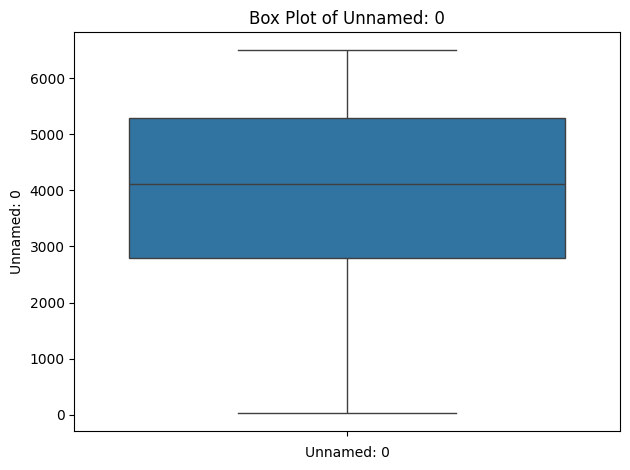

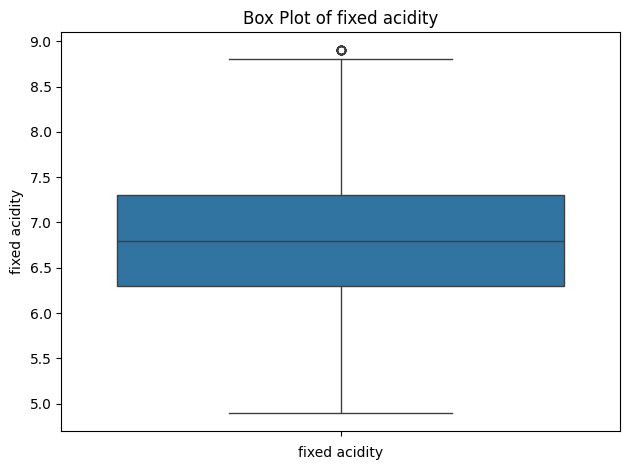

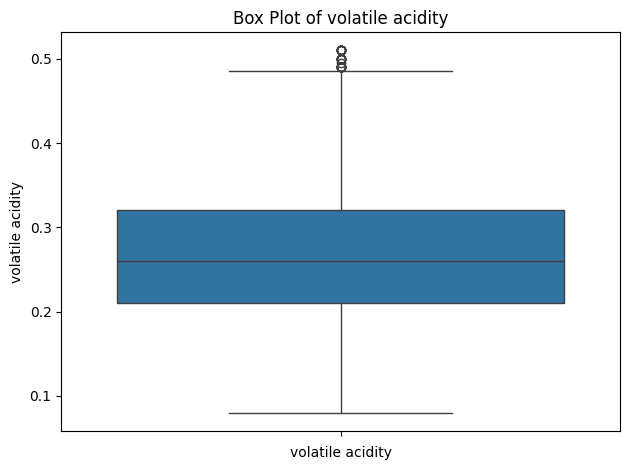

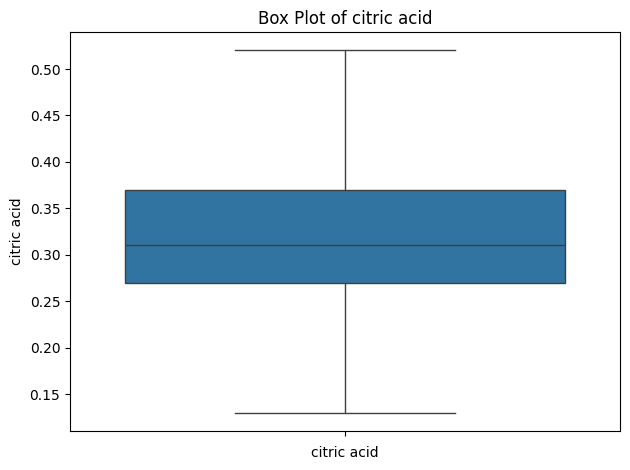

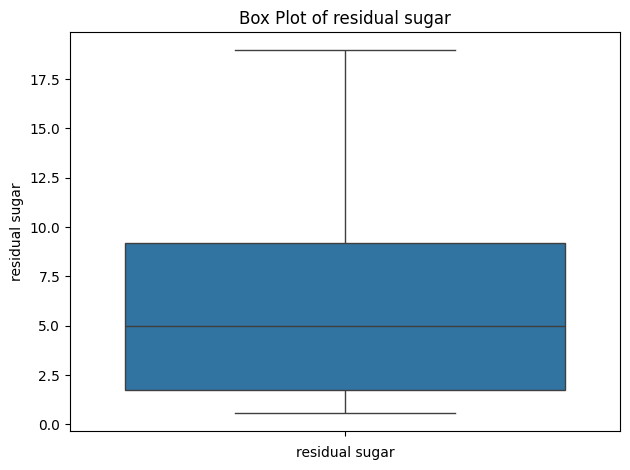

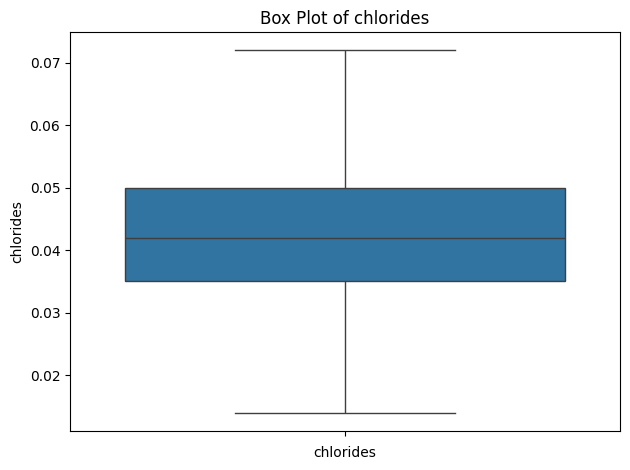

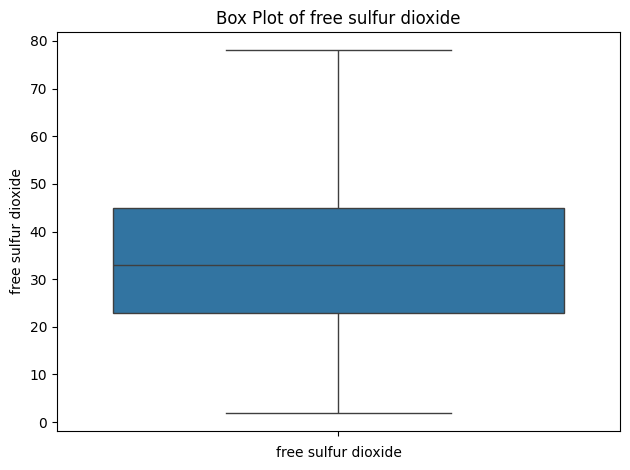

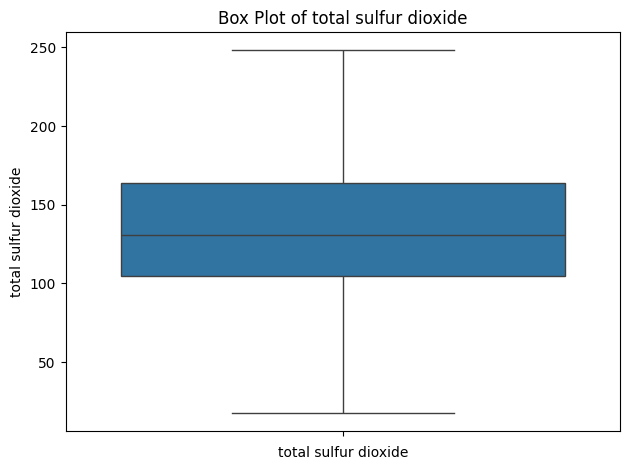

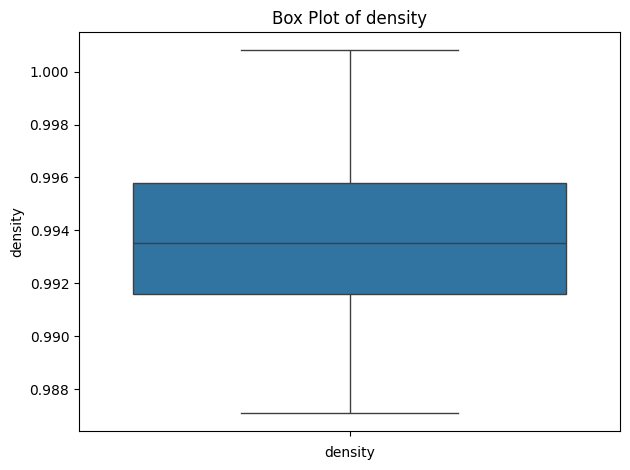

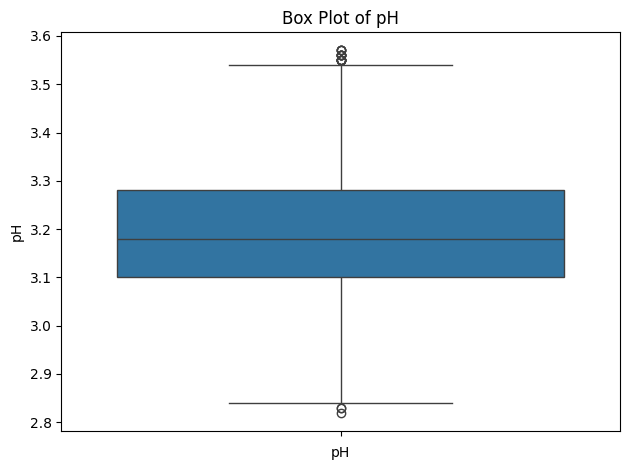

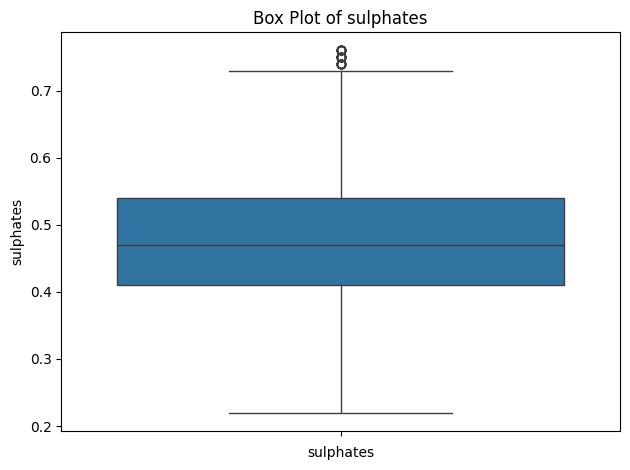

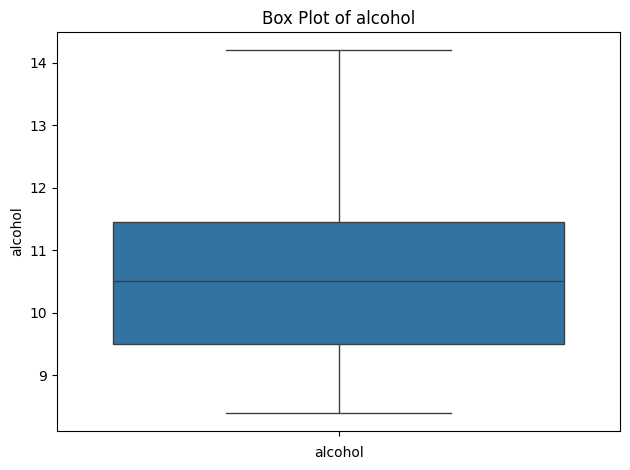

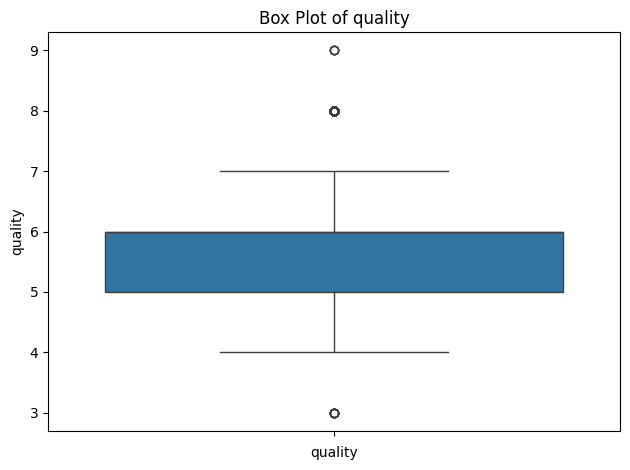

In [20]:
box_plot(df_cleaned)

After the removal of all the outliers, let's check the distribution of the whole data once again

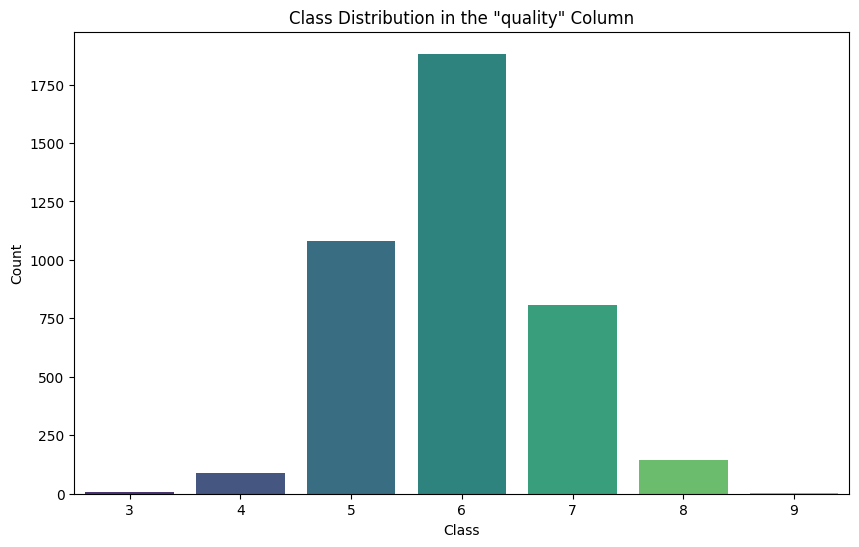

In [21]:
bar_chart(df_cleaned['quality'].value_counts())

# Feature Engineering

### Co Relation analysis

In [22]:
df_cleaned.corr()

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Unnamed: 0,1.000000,-0.282277,-0.023551,-0.168019,0.044657,-0.142049,0.035848,-0.067630,-0.192148,-0.189244,-0.050990,0.172213,0.019122
fixed acidity,-0.282277,1.000000,-0.010290,0.252231,0.044787,0.111764,-0.054752,0.048371,0.232149,-0.359501,0.008401,-0.083063,-0.060552
volatile acidity,-0.023551,-0.010290,1.000000,-0.130840,0.045336,0.026396,-0.084336,0.074148,0.000777,0.001615,0.020360,0.119740,-0.111470
citric acid,-0.168019,0.252231,-0.130840,1.000000,-0.019156,0.002532,0.059268,0.067695,0.031930,-0.074872,0.063701,0.022757,0.029457
residual sugar,0.044657,0.044787,0.045336,-0.019156,1.000000,0.244258,0.354523,0.419099,0.819559,-0.187712,-0.059886,-0.478631,-0.096207
chlorides,-0.142049,0.111764,0.026396,0.002532,0.244258,1.000000,0.120405,0.284750,0.506901,0.021590,0.125391,-0.519548,-0.266400
free sulfur dioxide,0.035848,-0.054752,-0.084336,0.059268,0.354523,0.120405,1.000000,0.626241,0.313001,-0.035534,0.020838,-0.254503,0.024640
total sulfur dioxide,-0.067630,0.048371,0.074148,0.067695,0.419099,0.284750,0.626241,1.000000,0.506365,-0.032032,0.067887,-0.458604,-0.160621
density,-0.192148,0.232149,0.000777,0.031930,0.819559,0.506901,0.313001,0.506365,1.000000,-0.037456,0.101788,-0.814238,-0.294572
pH,-0.189244,-0.359501,0.001615,-0.074872,-0.187712,0.021590,-0.035534,-0.032032,-0.037456,1.000000,0.162359,0.069794,0.057262


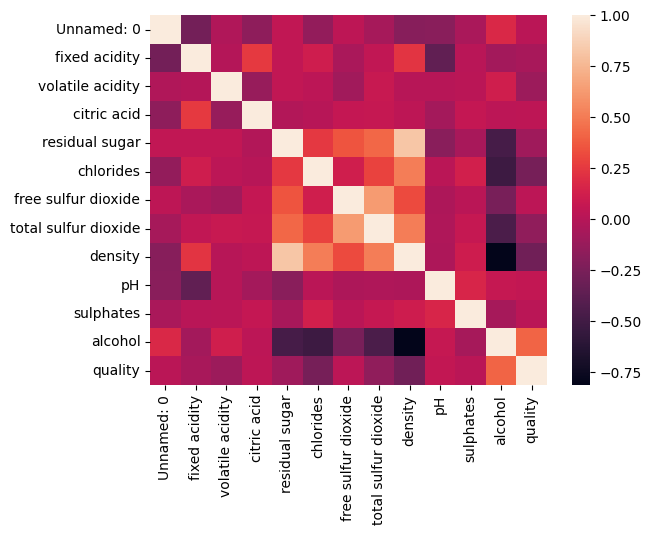

In [23]:
ax = sns.heatmap(df_cleaned.corr())

It shows that no 2 columns are highly co related. There is 81% co relation of residual sugar and density that can be tolerated.

Let's check the importance of every feature in the prediction of the quality of wine using Co Relation.

### Co Relation With Quality Analysis

In [37]:
corr_matrix = df_cleaned.corr()['quality']
corr_matrix

Unnamed: 0              0.019122
fixed acidity          -0.060552
volatile acidity       -0.111470
citric acid             0.029457
residual sugar         -0.096207
chlorides              -0.266400
free sulfur dioxide     0.024640
total sulfur dioxide   -0.160621
density                -0.294572
pH                      0.057262
sulphates               0.020409
alcohol                 0.410627
quality                 1.000000
Name: quality, dtype: float64

Any column who has threhold less than a certain value can not add much value to the prediction of the final quality. Dropping the columns whose values are less than a particular threshold.

In [38]:
THRESHOLD = 0.05
drop_columns = []
for i, column in enumerate(df_cleaned.columns):
    if abs(corr_matrix[i]) < THRESHOLD:
        drop_columns.append(column)

In [39]:
drop_columns

['Unnamed: 0', 'citric acid', 'free sulfur dioxide', 'sulphates']

In [40]:
feature_removed = df_cleaned.drop(columns = drop_columns)
feature_removed

,fixed acidity,volatile acidity,residual sugar,chlorides,total sulfur dioxide,density,pH,alcohol,quality
37,8.1,0.38,2.1,0.066,30.0,0.99680,3.23,9.7,7
87,7.7,0.49,1.9,0.062,31.0,0.99660,3.39,9.6,5
93,7.7,0.49,1.9,0.062,31.0,0.99660,3.39,9.6,5
97,7.0,0.50,2.0,0.070,22.0,0.99630,3.25,9.2,5
104,7.2,0.49,2.2,0.070,36.0,0.99600,3.33,9.4,5
...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,1.6,0.039,92.0,0.99114,3.27,11.2,6
6493,6.6,0.32,8.0,0.047,168.0,0.99490,3.15,9.6,5
6494,6.5,0.24,1.2,0.041,111.0,0.99254,2.99,9.4,6
6495,5.5,0.29,1.1,0.022,110.0,0.98869,3.34,12.8,7


In [41]:
feature_removed.columns

Index(['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides',
       'total sulfur dioxide', 'density', 'pH', 'alcohol', 'quality'],
      dtype='object')

### Train Test Split

In [42]:
X = feature_removed.drop(['quality'], axis = 1)
y = feature_removed['quality']

In [43]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Feature Scaling

In [44]:
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
X_train

array([[-0.57059827, -0.46311245,  0.87871419, ...,  1.03174443,
         0.26220204, -1.16569677],
       [-0.1707049 , -1.8474604 , -0.80231392, ..., -0.53575811,
        -0.89341834, -0.423992  ],
       [ 0.89567743, -0.085563  , -0.08787697, ..., -0.14832551,
        -0.4600607 ,  0.4001244 ],
       ...,
       [ 1.02897522, -1.34406115, -0.99142958, ..., -0.2123052 ,
        -0.60451325, -0.25916872],
       [-1.50368281, -0.58896226,  2.07644671, ...,  1.71419451,
         0.18997576, -1.41293169],
       [-1.10378943,  0.16613663,  2.45467803, ...,  1.83504505,
        -0.67673952, -1.41293169]])

Now, or dataset is ready to apply the machine learning models. Let's try the models.

# Model Selection

In [46]:
# Initialize the models
models = {
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Support Vector Machine': SVC()
}


In [57]:

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    print(f"\n{name} Performance:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



Training Logistic Regression...

Logistic Regression Performance:
Accuracy: 0.5174129353233831
Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        18
           5       0.46      0.35      0.40       199
           6       0.54      0.81      0.65       399
           7       0.46      0.15      0.22       157
           8       0.00      0.00      0.00        28

    accuracy                           0.52       804
   macro avg       0.24      0.22      0.21       804
weighted avg       0.47      0.52      0.46       804

Confusion Matrix:
[[  0   0   1   1   1   0]
 [  0   0   5  12   1   0]
 [  0   0  70 128   1   0]
 [  0   0  56 323  20   0]
 [  0   0  16 118  23   0]
 [  0   0   5  19   4   0]]

Training K-Nearest Neighbors...

K-Nearest Neighbors Performance:
Accuracy: 0.5261194029850746
Classification Report:
              precision    recall  f1-

This shows that the accuracy is pretty less by every model which is < 60%. Let's try to apply hyperparameter tuning.

# Hyper Parameter Tuning

### Decision Tree

In [50]:
# Create a Decision Tree model
dt = DecisionTreeClassifier()

# Define the hyperparameter grid to search
param_grid = {dt
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Evaluate the best model
print("Best Hyperparameters:", grid_search.best_params_)
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters: {'criterion': 'entropy', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy on Test Set: 0.6082089552238806
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.18      0.11      0.14        18
           5       0.55      0.56      0.56       199
           6       0.69      0.66      0.68       399
           7       0.59      0.63      0.61       157
           8       0.28      0.39      0.32        28
           9       0.00      0.00      0.00         0

    accuracy                           0.61       804
   macro avg       0.33      0.34      0.33       804
weighted avg       0.61      0.61      0.61       804



### Logistic Regression

In [51]:
# Create a Logistic Regression model
log_reg = LogisticRegression(solver='liblinear')  # 'liblinear' is a good choice for small datasets

# Define the hyperparameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization strength
    'penalty': ['l1', 'l2'],  # Type of regularization
    'solver': ['liblinear', 'saga']  # Optimization algorithm
}

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit the GridSearchCV
grid_search.fit(X_train, y_train)

# Get the best model
best_model = grid_search.best_estimator_

# Predict on the test set
y_pred = best_model.predict(X_test)

# Evaluate the best model
print("Best Hyperparameters:", grid_search.best_params_)
print("Accuracy on Test Set:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Accuracy on Test Set: 0.5211442786069652
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        18
           5       0.46      0.35      0.40       199
           6       0.54      0.82      0.65       399
           7       0.47      0.15      0.22       157
           8       0.00      0.00      0.00        28

    accuracy                           0.52       804
   macro avg       0.25      0.22      0.21       804
weighted avg       0.47      0.52      0.47       804



On First Turn, The accuracy did not go more than >60 %. Let's try to apply PCA.

# PCA

In [58]:
# Apply PCA
pca = PCA()  
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

**Analysis:** The accuracy was about 60.8 or 61% even after applying PCA. The main reason for this low accuracy is huge class imbalances between various qualities. This can be done by eliminating the data to equate each class, resulting in drastic data loss. The other possible way is to collect more data. Since, it is the data acquated in laboratory so it is possible to reproduce only in laboratory.

# Saving the model

In [71]:
dt = DecisionTreeClassifier(criterion =  'entropy', max_depth = 50, max_features = 'sqrt', min_samples_leaf =  1, min_samples_split= 2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=50, max_features='sqrt')

In [72]:
joblib.dump(dt, 'DecisionTree.pkl')

['DecisionTree.pkl']

In [73]:
joblib.dump(scaler, 'Scaler.pkl')

['Scaler.pkl']

# Prediction

In [74]:
feature_removed.columns


Index(['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides',
       'total sulfur dioxide', 'density', 'pH', 'alcohol', 'quality'],
      dtype='object')